# Dataset Audit — Driver Drowsiness

A first model trained on a public Roboflow dataset reached mAP@50 = 0.514
with precision 0.372. This notebook finds out why, and rebuilds the dataset.

Set `ROBOFLOW_API_KEY` in Colab's secrets panel before running.


In [ ]:
!pip install roboflow -q

from roboflow import Roboflow

import os
rf = Roboflow(api_key=os.environ.get("ROBOFLOW_API_KEY", ""))
ws = rf.workspace("kara-aawmz")

print("=== TES PROJETS ROBOFLOW ===\n")
for p in ws.projects():
    proj = ws.project(p.split("/")[-1])
    versions = [v.version for v in proj.versions()]
    print(f"  slug     : {p.split('/')[-1]}")
    print(f"  nom      : {proj.name}")
    print(f"  classes  : {proj.classes}")
    print(f"  versions : {versions}")
    print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.7 MB/s eta 0:00:00
loading Roboflow workspace...
=== TES PROJETS ROBOFLOW ===

loading Roboflow project...
  slug     : drowsiness-detection-luvay-wvdir
  nom      : Drowsiness Detection
  classes  : {'Closed-Eye': 729, 'Open-Eye': 728, 'Yawn': 700}
  versions : ['1']

loading Roboflow project...
  slug     : drowsiness-driver-sw14t
  nom      : drowsiness driver
  classes  : {'close': 1023, 'Drowsy eye': 1963, 'Open-Mouth': 720, 'Attentive eye': 2191, 'asleep': 404, 'Yawn': 1043, 'closed': 393, 'Eyeclosed': 485, 'yawn': 1047, 'open': 2795, 'noYawn': 750}
  versions : ['1']



## 1. Which dataset produced the delivered model?

The published notebook trained on a 3-class dataset, but the delivered
`drowsy_v2.pt` has 11 classes. They do not match. A `.pt` checkpoint stores
its training arguments, so the origin can be recovered from the file itself.

In [ ]:
!pip install ultralytics -q

from ultralytics import YOLO
m = YOLO("drowsy_v2.pt")
print("NOMBRE DE CLASSES :", len(m.names))
print("CLASSES DU MODELE :", m.names)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
NOMBRE DE CLASSES : 11
CLASSES DU MODELE : {0: 'Attentive eye', 1: 'Drowsy eye', 2: 'Eyeclosed', 3: 'Open-Mouth', 4: 'Yawn', 5: 'asleep', 6: 'close', 7: 'closed', 8: 'noYawn', 9: 'open', 10: 'yawn'}


In [ ]:
import torch
ckpt = torch.load("drowsy_v2.pt", map_location="cpu", weights_only=False)

print("DATE :", ckpt.get("date"))
print("EPOCH :", ckpt.get("epoch"))
print("\n--- ARGUMENTS D'ENTRAINEMENT ---")
args = ckpt.get("train_args", {})
for k in ["data", "model", "epochs", "imgsz", "batch", "device", "project", "name"]:
    print(f"{k:10} : {args.get(k)}")

print("\n--- METRIQUES SAUVEGARDEES ---")
print(ckpt.get("train_metrics"))
print(ckpt.get("best_fitness"))

DATE : 2025-12-30T04:20:56.412817
EPOCH : -1

--- ARGUMENTS D'ENTRAINEMENT ---
data       : drowsiness-driver-1/data.yaml
model      : yolov8n.pt
epochs     : 30
imgsz      : 640
batch      : 16
device     : None
project    : None
name       : drowsy_v2

--- METRIQUES SAUVEGARDEES ---
{'metrics/precision(B)': 0.37219, 'metrics/recall(B)': 0.81439, 'metrics/mAP50(B)': 0.51401, 'metrics/mAP50-95(B)': 0.31071, 'val/box_loss': 1.41119, 'val/cls_loss': 1.47424, 'val/dfl_loss': 1.55829, 'fitness': 0.31071}
None


## 2. Class inventory and box scale

Counting annotations is not enough. Measuring the median box area per class
reveals whether the classes annotate the same kind of object at all.


In [ ]:
import os, collections, yaml, statistics

proj = ws.project("drowsiness-driver-sw14t")
ds = proj.version(1).download("yolov8")
print("\nTelecharge dans :", ds.location, "\n")

with open(os.path.join(ds.location, "data.yaml")) as f:
    names = yaml.safe_load(f)["names"]

# aire de chaque boite (w*h en fraction de l'image), par classe
areas = collections.defaultdict(list)
per_image_classes = []

for split in ["train", "valid", "test"]:
    d = os.path.join(ds.location, split, "labels")
    if not os.path.isdir(d):
        continue
    for fn in os.listdir(d):
        if not fn.endswith(".txt"):
            continue
        cls_in_img = set()
        for line in open(os.path.join(d, fn)):
            p = line.split()
            if len(p) >= 5:
                cid = int(p[0])
                areas[cid].append(float(p[3]) * float(p[4]))
                cls_in_img.add(cid)
        if cls_in_img:
            per_image_classes.append(cls_in_img)

print(f"{'id':>3} {'classe':<15} {'n':>6} {'aire med':>9} {'% image':>8}")
print("-" * 46)
for cid in sorted(areas):
    a = areas[cid]
    med = statistics.median(a)
    print(f"{cid:>3} {names[cid]:<15} {len(a):>6} {med:>9.4f} {med*100:>7.1f}%")

# quelles classes apparaissent ensemble sur une meme image ?
print("\n=== PAIRES LES PLUS FREQUENTES SUR UNE MEME IMAGE ===")
pairs = collections.Counter()
for s in per_image_classes:
    for a in s:
        for b in s:
            if a < b:
                pairs[(a, b)] += 1
for (a, b), n in pairs.most_common(12):
    print(f"  {names[a]:<15} + {names[b]:<15} : {n}")

print("\n=== NB DE CLASSES PAR IMAGE ===")
print(collections.Counter(len(s) for s in per_image_classes))

loading Roboflow project...



Extracting Dataset Version Zip to drowsiness-driver-1 in yolov8:: 100%|██████████| 19399/19399 [00:02<00:00, 7590.82it/s]



Telecharge dans : /content/drowsiness-driver-1 

 id classe               n  aire med  % image
----------------------------------------------
  0 Attentive eye     2191    0.0046     0.5%
  1 Drowsy eye        1963    0.0270     2.7%
  2 Eyeclosed          485    0.1022    10.2%
  3 Open-Mouth         720    0.0188     1.9%
  4 Yawn              1043    0.1042    10.4%
  5 asleep             404    0.0100     1.0%
  6 close             1023    0.3617    36.2%
  7 closed             393    0.0111     1.1%
  8 noYawn             750    0.1135    11.3%
  9 open              2795    0.0048     0.5%
 10 yawn              1047    0.0171     1.7%

=== PAIRES LES PLUS FREQUENTES SUR UNE MEME IMAGE ===
  closed          + yawn            : 393
  open            + yawn            : 314
  Attentive eye   + Drowsy eye      : 12
  close           + open            : 11

=== NB DE CLASSES PAR IMAGE ===
Counter({1: 8964, 2: 730})


## 3. Visual inspection

Statistics suggest, images decide. Three samples per class, with the
annotation drawn.

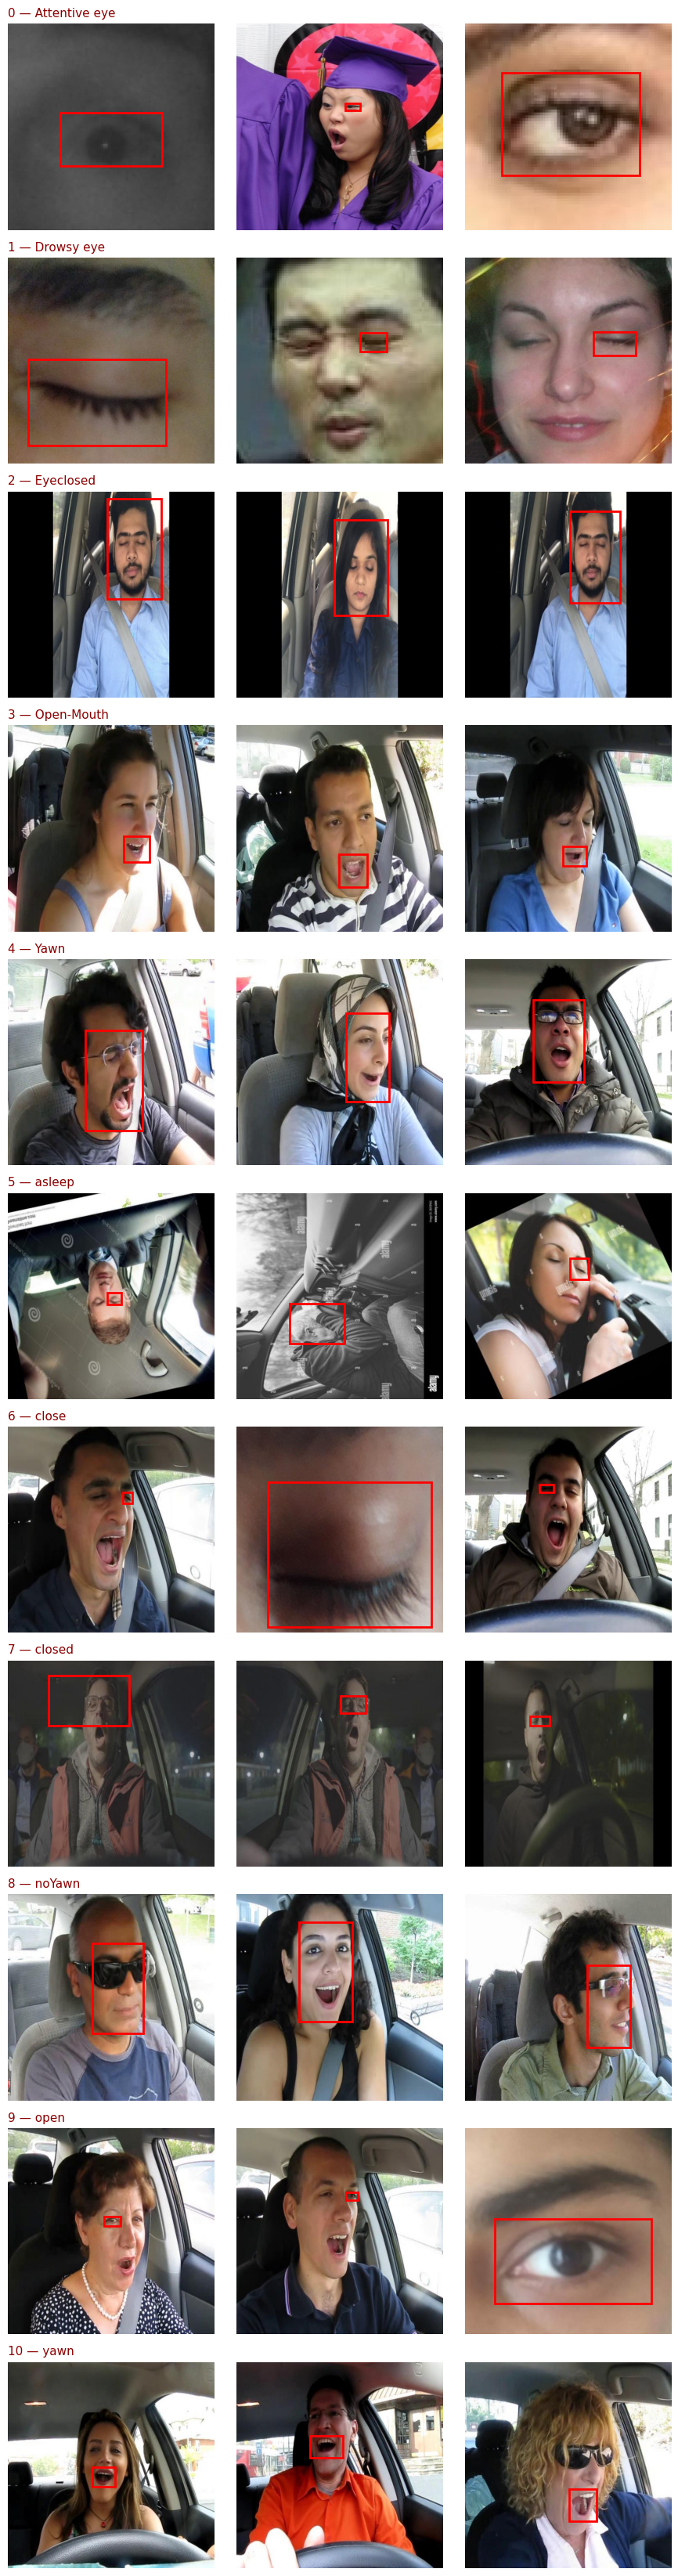

In [ ]:
import os, random, collections
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

root = ds.location
samples = collections.defaultdict(list)

for split in ["train", "valid"]:
    ld = os.path.join(root, split, "labels")
    imd = os.path.join(root, split, "images")
    if not os.path.isdir(ld):
        continue
    for fn in os.listdir(ld):
        if not fn.endswith(".txt"):
            continue
        for line in open(os.path.join(ld, fn)):
            p = line.split()
            if len(p) >= 5:
                cid = int(p[0])
                if len(samples[cid]) < 40:
                    stem = fn[:-4]
                    for ext in [".jpg", ".jpeg", ".png"]:
                        ip = os.path.join(imd, stem + ext)
                        if os.path.exists(ip):
                            samples[cid].append((ip, list(map(float, p[1:5]))))
                            break

random.seed(0)
fig, axes = plt.subplots(11, 3, figsize=(9, 33))

for cid in range(11):
    picks = random.sample(samples[cid], min(3, len(samples[cid])))
    for j in range(3):
        ax = axes[cid, j]
        ax.axis("off")
        if j >= len(picks):
            continue
        ip, (xc, yc, bw, bh) = picks[j]
        img = Image.open(ip)
        W, H = img.size
        ax.imshow(img)
        ax.add_patch(patches.Rectangle(
            ((xc - bw/2)*W, (yc - bh/2)*H), bw*W, bh*H,
            linewidth=2, edgecolor="red", facecolor="none"))
        if j == 0:
            ax.set_title(f"{cid} — {names[cid]}", fontsize=11,
                         loc="left", color="darkred")

plt.tight_layout()
plt.show()

In [ ]:
import os, collections
from PIL import Image

root = ds.location
rows = []

for split in ["train", "valid", "test"]:
    ld = os.path.join(root, split, "labels")
    imd = os.path.join(root, split, "images")
    if not os.path.isdir(ld):
        continue
    for fn in os.listdir(ld):
        if not fn.endswith(".txt"):
            continue
        stem = fn[:-4]
        ip = None
        for ext in [".jpg", ".jpeg", ".png"]:
            cand = os.path.join(imd, stem + ext)
            if os.path.exists(cand):
                ip = cand
                break
        if ip is None:
            continue
        W, H = Image.open(ip).size
        for line in open(os.path.join(ld, fn)):
            p = line.split()
            if len(p) >= 5:
                rows.append((split, int(p[0]), W, H, float(p[3])*float(p[4])))

# taille d'image la plus frequente par classe
print(f"{'id':>3} {'classe':<15} {'n':>6}  resolutions dominantes")
print("-"*70)
for cid in range(11):
    r = [x for x in rows if x[1] == cid]
    res = collections.Counter((x[2], x[3]) for x in r)
    top = "  ".join(f"{w}x{h}({n})" for (w, h), n in res.most_common(3))
    print(f"{cid:>3} {names[cid]:<15} {len(r):>6}  {top}")

# combien d'annotations sont des gros plans (boite > 15% de l'image)
print("\n=== ANNOTATIONS AVEC BOITE > 15% DE L'IMAGE (= vignette probable) ===")
for cid in range(11):
    r = [x for x in rows if x[1] == cid]
    big = sum(1 for x in r if x[4] > 0.15)
    if r:
        print(f"  {names[cid]:<15} : {big:>5} / {len(r):<5} ({100*big/len(r):.0f}%)")

 id classe               n  resolutions dominantes
----------------------------------------------------------------------
  0 Attentive eye     2191  512x512(2191)
  1 Drowsy eye        1963  512x512(1963)
  2 Eyeclosed          485  512x512(485)
  3 Open-Mouth         720  512x512(720)
  4 Yawn              1043  512x512(1043)
  5 asleep             404  512x512(404)
  6 close             1023  512x512(1023)
  7 closed             393  512x512(393)
  8 noYawn             750  512x512(750)
  9 open              2795  512x512(2795)
 10 yawn              1047  512x512(1047)

=== ANNOTATIONS AVEC BOITE > 15% DE L'IMAGE (= vignette probable) ===
  Attentive eye   :   635 / 2191  (29%)
  Drowsy eye      :   901 / 1963  (46%)
  Eyeclosed       :     3 / 485   (1%)
  Open-Mouth      :     0 / 720   (0%)
  Yawn            :   195 / 1043  (19%)
  asleep          :    40 / 404   (10%)
  close           :   676 / 1023  (66%)
  closed          :    31 / 393   (8%)
  noYawn          :    62 / 750  

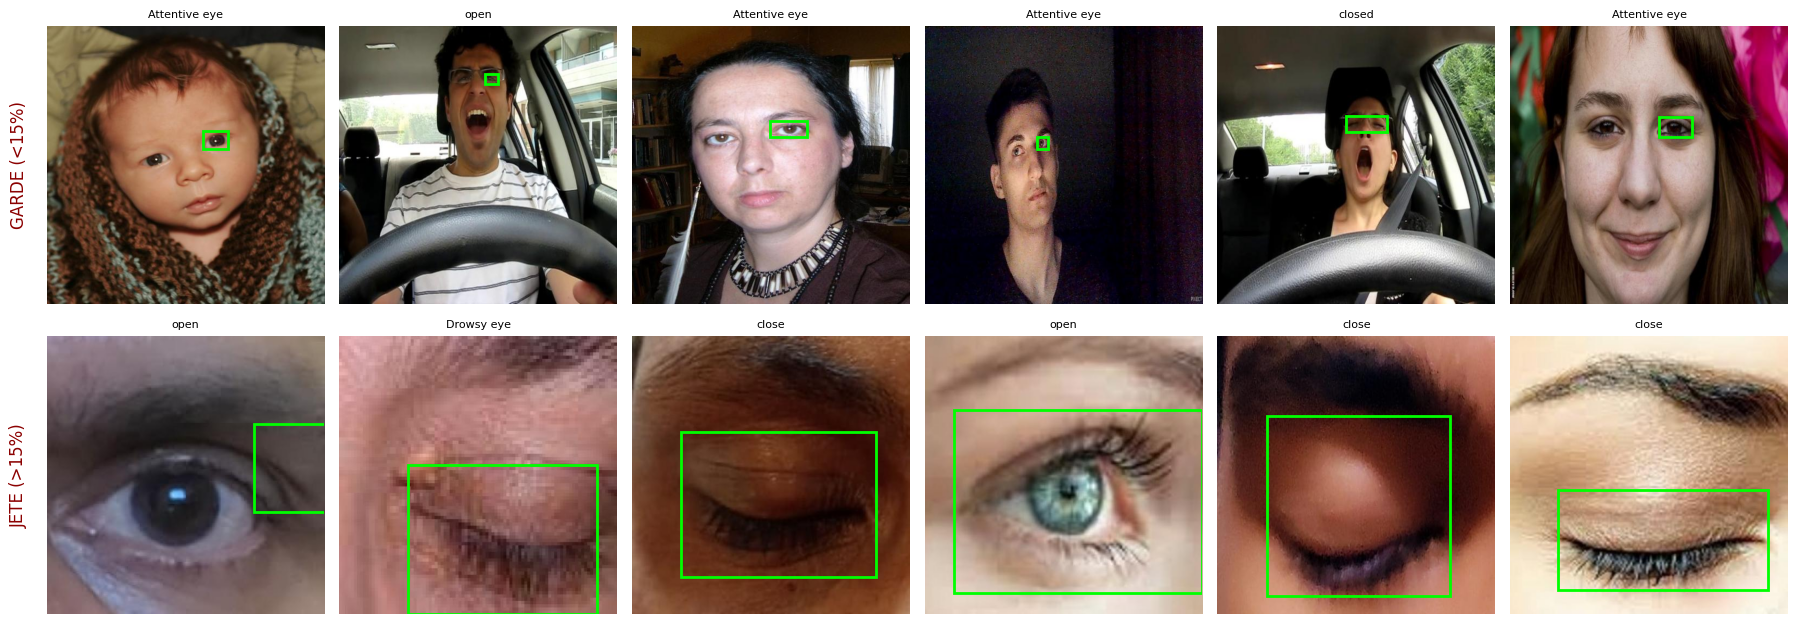

In [ ]:
import os, random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

random.seed(1)
root = ds.location
buckets = {"GARDE (<15%)": [], "JETE (>15%)": []}

for split in ["train", "valid"]:
    ld = os.path.join(root, split, "labels")
    imd = os.path.join(root, split, "images")
    if not os.path.isdir(ld):
        continue
    for fn in os.listdir(ld):
        if not fn.endswith(".txt"):
            continue
        for line in open(os.path.join(ld, fn)):
            p = line.split()
            if len(p) < 5 or int(p[0]) not in (0, 1, 6, 7, 9):
                continue
            box = list(map(float, p[1:5]))
            area = box[2] * box[3]
            key = "JETE (>15%)" if area > 0.15 else "GARDE (<15%)"
            if len(buckets[key]) < 200:
                ip = os.path.join(imd, fn[:-4] + ".jpg")
                if os.path.exists(ip):
                    buckets[key].append((ip, box, names[int(p[0])]))

fig, axes = plt.subplots(2, 6, figsize=(18, 6.5))
for r, (key, items) in enumerate(buckets.items()):
    for c in range(6):
        ax = axes[r, c]
        ax.axis("off")
        if c >= len(items):
            continue
        ip, (xc, yc, bw, bh), cname = random.sample(items, 6)[c]
        img = Image.open(ip)
        W, H = img.size
        ax.imshow(img)
        ax.add_patch(patches.Rectangle(
            ((xc-bw/2)*W, (yc-bh/2)*H), bw*W, bh*H,
            linewidth=2, edgecolor="lime", facecolor="none"))
        ax.set_title(cname, fontsize=8)
        if c == 0:
            ax.text(-0.1, 0.5, key, transform=ax.transAxes, rotation=90,
                    va="center", ha="center", fontsize=12, color="darkred")
plt.tight_layout()
plt.show()

## 4. Cleaning

Drop the contradictory face-level classes and the close-up eye crops, merge
the synonyms, keep everything at a single scale.

In [ ]:
import os, shutil, collections, yaml

SRC = ds.location
DST = "/content/drowsy_clean"
AREA_MAX = 0.15

# ancien id -> nouveau id
REMAP = {
    0: 0,  # Attentive eye -> eye_open
    9: 0,  # open          -> eye_open
    1: 1,  # Drowsy eye    -> eye_closed
    6: 1,  # close         -> eye_closed
    7: 1,  # closed        -> eye_closed
    3: 2,  # Open-Mouth    -> mouth_open
   10: 3,  # yawn          -> yawn
}
NEW_NAMES = ["eye_open", "eye_closed", "mouth_open", "yawn"]

if os.path.exists(DST):
    shutil.rmtree(DST)

stats = collections.Counter()
kept_img, dropped_img = 0, 0

for split in ["train", "valid", "test"]:
    sl = os.path.join(SRC, split, "labels")
    si = os.path.join(SRC, split, "images")
    if not os.path.isdir(sl):
        continue
    dl = os.path.join(DST, split, "labels")
    di = os.path.join(DST, split, "images")
    os.makedirs(dl, exist_ok=True)
    os.makedirs(di, exist_ok=True)

    for fn in os.listdir(sl):
        if not fn.endswith(".txt"):
            continue
        out = []
        for line in open(os.path.join(sl, fn)):
            p = line.split()
            if len(p) < 5:
                continue
            cid = int(p[0])
            if cid not in REMAP:
                continue
            w, h = float(p[3]), float(p[4])
            if w * h > AREA_MAX:
                continue
            new_id = REMAP[cid]
            out.append(f"{new_id} {p[1]} {p[2]} {p[3]} {p[4]}")
            stats[(split, new_id)] += 1

        if not out:                      # image sans annotation valide
            dropped_img += 1
            continue

        src_img = None
        for ext in [".jpg", ".jpeg", ".png"]:
            c = os.path.join(si, fn[:-4] + ext)
            if os.path.exists(c):
                src_img = c
                break
        if src_img is None:
            dropped_img += 1
            continue

        shutil.copy(src_img, os.path.join(di, os.path.basename(src_img)))
        with open(os.path.join(dl, fn), "w") as f:
            f.write("\n".join(out) + "\n")
        kept_img += 1

with open(os.path.join(DST, "data.yaml"), "w") as f:
    yaml.dump({
        "path": DST,
        "train": "train/images",
        "val": "valid/images",
        "test": "test/images",
        "nc": len(NEW_NAMES),
        "names": NEW_NAMES,
    }, f, sort_keys=False)

print(f"Images gardees : {kept_img}    supprimees : {dropped_img}\n")
print(f"{'split':<8}{'classe':<14}{'n':>7}")
print("-"*30)
for split in ["train", "valid", "test"]:
    for i, n in enumerate(NEW_NAMES):
        c = stats[(split, i)]
        if c:
            print(f"{split:<8}{n:<14}{c:>7}")
    print()
print("data.yaml ecrit dans", DST)

Images gardees : 4163    supprimees : 5531

split   classe              n
------------------------------
train   eye_open         1466
train   eye_closed       1000
train   mouth_open        505
train   yawn              721

valid   eye_open         1083
valid   eye_closed        291
valid   mouth_open        142
valid   yawn              184

test    eye_open         1094
test    eye_closed        480
test    mouth_open         73
test    yawn              109

data.yaml ecrit dans /content/drowsy_clean


## 5. Stratified split

The original split left `mouth_open` entirely absent from validation and
test. Each class is re-split 70/20/10 independently.

In [ ]:
import os, shutil, collections, random, re, yaml

SRC = "/content/drowsy_clean"
DST = "/content/drowsy_final"
random.seed(42)

items = []
for split in ["train", "valid", "test"]:
    ld = os.path.join(SRC, split, "labels")
    if not os.path.isdir(ld):
        continue
    for fn in os.listdir(ld):
        if not fn.endswith(".txt"):
            continue
        lp = os.path.join(ld, fn)
        ip = None
        for ext in [".jpg", ".jpeg", ".png"]:
            c = os.path.join(SRC, split, "images", fn[:-4] + ext)
            if os.path.exists(c):
                ip = c
                break
        if ip is None:
            continue
        counts = collections.Counter(int(l.split()[0]) for l in open(lp) if l.strip())
        if not counts:
            continue
        stem = re.split(r"\.rf\.", fn)[0]
        group = re.sub(r"[\d]+$", "", stem)[:22]
        items.append({"lp": lp, "ip": ip, "counts": counts,
                      "dom": counts.most_common(1)[0][0], "group": group})

# groupes, classes par groupe
by_group = collections.defaultdict(list)
for it in items:
    by_group[it["group"]].append(it)

# classe dominante de chaque groupe
group_class = {}
for g, lst in by_group.items():
    c = collections.Counter()
    for it in lst:
        c.update(it["counts"])
    group_class[g] = c.most_common(1)[0][0]

# repartition 70/20/10 INDEPENDANTE pour chaque classe
assigned = {"train": [], "valid": [], "test": []}
for cid in range(4):
    gs = [g for g, c in group_class.items() if c == cid]
    random.shuffle(gs)
    n_ann = {g: sum(sum(it["counts"].values()) for it in by_group[g]) for g in gs}
    tot = sum(n_ann.values())
    acc, dest = 0, "train"
    for g in gs:
        r = acc / max(tot, 1)
        dest = "train" if r < 0.70 else ("valid" if r < 0.90 else "test")
        assigned[dest].extend(by_group[g])
        acc += n_ann[g]

if os.path.exists(DST):
    shutil.rmtree(DST)
NEW_NAMES = ["eye_open", "eye_closed", "mouth_open", "yawn"]
stats = collections.Counter()

for split, lst in assigned.items():
    os.makedirs(os.path.join(DST, split, "images"), exist_ok=True)
    os.makedirs(os.path.join(DST, split, "labels"), exist_ok=True)
    for it in lst:
        shutil.copy(it["ip"], os.path.join(DST, split, "images", os.path.basename(it["ip"])))
        shutil.copy(it["lp"], os.path.join(DST, split, "labels", os.path.basename(it["lp"])))
        for k, v in it["counts"].items():
            stats[(split, k)] += v

with open(os.path.join(DST, "data.yaml"), "w") as f:
    yaml.dump({"path": DST, "train": "train/images", "val": "valid/images",
               "test": "test/images", "nc": 4, "names": NEW_NAMES}, f, sort_keys=False)

total = len(items)
print(f"{'split':<8}{'images':>8}{'%':>6}   ", "  ".join(f"{n:>13}" for n in NEW_NAMES))
print("-"*80)
for split in ["train", "valid", "test"]:
    n_img = len(assigned[split])
    tot = sum(stats[(split, i)] for i in range(4))
    props = "  ".join(f"{stats[(split,i)]:>5} ({100*stats[(split,i)]/max(tot,1):>4.1f}%)" for i in range(4))
    print(f"{split:<8}{n_img:>8}{100*n_img/total:>5.0f}%   {props}")

print("\n=== REPARTITION DE CHAQUE CLASSE ENTRE LES SPLITS (cible 70/20/10) ===")
for i, n in enumerate(NEW_NAMES):
    t = sum(stats[(s, i)] for s in ["train", "valid", "test"])
    line = "  ".join(f"{s}:{100*stats[(s,i)]/max(t,1):>4.0f}%" for s in ["train", "valid", "test"])
    print(f"  {n:<12} n={t:<6} {line}")

split     images     %         eye_open     eye_closed     mouth_open           yawn
--------------------------------------------------------------------------------
train       2920   70%    2541 (50.7%)   1252 (25.0%)    507 (10.1%)    714 (14.2%)
valid        824   20%     736 (51.6%)    353 (24.8%)    142 (10.0%)    195 (13.7%)
test         419   10%     366 (51.7%)    166 (23.4%)     71 (10.0%)    105 (14.8%)

=== REPARTITION DE CHAQUE CLASSE ENTRE LES SPLITS (cible 70/20/10) ===
  eye_open     n=3643   train:  70%  valid:  20%  test:  10%
  eye_closed   n=1771   train:  71%  valid:  20%  test:   9%
  mouth_open   n=720    train:  70%  valid:  20%  test:  10%
  yawn         n=1014   train:  70%  valid:  19%  test:  10%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/drowsy', exist_ok=True)
shutil.make_archive('/content/drive/MyDrive/drowsy/drowsy_final', 'zip', '/content/drowsy_final')
print("Sauvegarde OK")

Mounted at /content/drive
Sauvegarde OK


In [ ]:
import yaml
cfg = {"path": "/content/drowsy_final", "train": "train/images",
       "val": "valid/images", "test": "test/images",
       "nc": 4, "names": ["eye_open", "eye_closed", "mouth_open", "yawn"]}
with open('/content/drowsy_final/data.yaml', 'w') as f:
    yaml.dump(cfg, f, sort_keys=False)
print(open('/content/drowsy_final/data.yaml').read())

path: /content/drowsy_final
train: train/images
val: valid/images
test: test/images
nc: 4
names:
- eye_open
- eye_closed
- mouth_open
- yawn



## 6. Training

Same hyperparameters across versions, only the number of classes changes.
One variable at a time.

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='/content/drowsy_final/data.yaml',
    epochs=80,
    imgsz=640,
    batch=32,
    patience=20,
    seed=42,
    deterministic=True,
    project='/content/drive/MyDrive/drowsy',
    name='v3_clean',
    plots=True,
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drowsy_final/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0

In [ ]:
import os, shutil, yaml, collections

SRC = "/content/drowsy_final"
DST = "/content/drowsy_3cls"

# ancien -> nouveau.  yawn (3) fusionne dans mouth_open (2)
REMAP = {0: 0, 1: 1, 2: 2, 3: 2}
NEW_NAMES = ["eye_open", "eye_closed", "mouth_open"]

if os.path.exists(DST):
    shutil.rmtree(DST)

stats = collections.Counter()

for split in ["train", "valid", "test"]:
    sl = os.path.join(SRC, split, "labels")
    si = os.path.join(SRC, split, "images")
    if not os.path.isdir(sl):
        continue
    dl = os.path.join(DST, split, "labels")
    di = os.path.join(DST, split, "images")
    os.makedirs(dl, exist_ok=True)
    os.makedirs(di, exist_ok=True)

    for fn in os.listdir(sl):
        if not fn.endswith(".txt"):
            continue
        out = []
        for line in open(os.path.join(sl, fn)):
            p = line.split()
            if len(p) >= 5:
                new_id = REMAP[int(p[0])]
                out.append(f"{new_id} {p[1]} {p[2]} {p[3]} {p[4]}")
                stats[(split, new_id)] += 1
        if not out:
            continue
        for ext in [".jpg", ".jpeg", ".png"]:
            sp = os.path.join(si, fn[:-4] + ext)
            if os.path.exists(sp):
                shutil.copy(sp, os.path.join(di, os.path.basename(sp)))
                break
        with open(os.path.join(dl, fn), "w") as f:
            f.write("\n".join(out) + "\n")

with open(os.path.join(DST, "data.yaml"), "w") as f:
    yaml.dump({"path": DST, "train": "train/images", "val": "valid/images",
               "test": "test/images", "nc": 3, "names": NEW_NAMES}, f, sort_keys=False)

for split in ["train", "valid", "test"]:
    tot = sum(stats[(split, i)] for i in range(3))
    line = "  ".join(f"{NEW_NAMES[i]}={stats[(split,i)]}" for i in range(3))
    print(f"{split:<7} total={tot:<6} {line}")

train   total=5014   eye_open=2541  eye_closed=1252  mouth_open=1221
valid   total=1426   eye_open=736  eye_closed=353  mouth_open=337
test    total=708    eye_open=366  eye_closed=166  mouth_open=176


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(
    data='/content/drowsy_3cls/data.yaml',
    epochs=80, imgsz=640, batch=32, patience=20,
    seed=42, deterministic=True,
    project='/content/drive/MyDrive/drowsy', name='v4_3cls',
    plots=True,
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.152 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drowsy_3cls/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b9f398db930>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04